## 1. Load data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8') # Hoặc 'ggplot'

def load_stock_price(industry, symbol, start_date, end_date):
    """
    Hàm đọc file giá của 1 mã chứng khoán.
    Lưu ý: Thay đổi đường dẫn 'Data_Cube' nếu bạn lưu ở chỗ khác.
    """
    path = f"Data_Cube/{industry}/{symbol}/Price_History.csv"
    
    if not os.path.exists(path):
        print(f"Không tìm thấy file: {path}")
        return None
    
    # Đọc CSV
    df = pd.read_csv(path)
    
    # Chuẩn hóa cột ngày tháng
    df['Ngay'] = pd.to_datetime(df['Ngay'])
    
    # Sắp xếp theo thời gian tăng dần
    df = df.sort_values('Ngay').reset_index(drop=True)

    # Filter by start_date and end_date
    if start_date:
        df = df[df['Ngay'] >= start_date]
    if end_date:
        df = df[df['Ngay'] <= end_date]
    
    return df

In [3]:
import os

# Cấu hình đường dẫn gốc
DATA_FOLDER = 'Data_Cube'

def get_list_industries(base_folder=DATA_FOLDER):
    """
    Lấy danh sách tất cả các ngành (tên thư mục cấp 1).
    """
    if not os.path.exists(base_folder):
        print(f"Lỗi: Thư mục '{base_folder}' không tồn tại.")
        return []
    
    # Lấy tất cả các mục trong folder gốc
    items = os.listdir(base_folder)
    
    # Lọc: Chỉ lấy thư mục (bỏ qua file csv hoặc file ẩn .DS_Store)
    industries = [
        item for item in items 
        if os.path.isdir(os.path.join(base_folder, item)) 
        and not item.startswith('.') # Bỏ qua file ẩn
    ]
    
    return sorted(industries)

def get_symbols_in_industry(industry_name, base_folder=DATA_FOLDER):
    """
    Lấy danh sách các mã cổ phiếu trong 1 ngành cụ thể.
    """
    industry_path = os.path.join(base_folder, industry_name)
    
    if not os.path.exists(industry_path):
        print(f"Lỗi: Ngành '{industry_name}' không tìm thấy trong dữ liệu.")
        return []
        
    items = os.listdir(industry_path)
    
    # Lọc: Chỉ lấy thư mục (mỗi mã cổ phiếu là 1 folder)
    symbols = [
        item for item in items 
        if os.path.isdir(os.path.join(industry_path, item))
        and not item.startswith('.')
    ]
    
    return sorted(symbols)



In [5]:

all_industries = get_list_industries()
print(f"Tìm thấy {len(all_industries)} ngành: {all_industries}")


# 2. Lấy danh sách mã của ngành đầu tiên (ví dụ)
if all_industries:
    first_industry = all_industries[0] # Ví dụ: 'BatDongSan_XayDung'
    stocks = get_symbols_in_industry(first_industry)

    
    print(f"\nDanh sách mã trong ngành '{first_industry}':")
    print(f"Tổng số: {len(stocks)} mã")
    print(f"5 mã đầu tiên: {stocks[:5]}")
  

Tìm thấy 11 ngành: ['BatDongSan_XayDung', 'CongNghe', 'CongNghiep', 'DichVu', 'HangTieuDung', 'NangLuong', 'NguyenVatLieu', 'NongNghiep', 'TaiChinh', 'VienThong', 'YTe']

Danh sách mã trong ngành 'BatDongSan_XayDung':
Tổng số: 407 mã
5 mã đầu tiên: ['AAV', 'ACC', 'ACS', 'AGG', 'ALV']


In [6]:
  
# 3. Gợi ý vòng lặp cho bài toán EDA toàn thị trường
ind_sym = {}

for ind in all_industries:
    symbols = get_symbols_in_industry(ind)
    ind_sym[ind] = symbols
    
for ind in ind_sym.keys():
    syms = ind_sym[ind]
    print(f"INDUSTRY:: {ind} :: {len(syms)} SYMS:: ")
    print(f"\t{syms}")
    print("-"*10)

INDUSTRY:: BatDongSan_XayDung :: 407 SYMS:: 
	['AAV', 'ACC', 'ACS', 'AGG', 'ALV', 'AME', 'ASM', 'BAX', 'BCC', 'BCE', 'BCM', 'BDT', 'BHC', 'BIG', 'BII', 'BMJ', 'BMP', 'BTD', 'BTN', 'BTS', 'BTU', 'BVL', 'C21', 'C32', 'C47', 'C4G', 'C69', 'C92', 'CBI', 'CC1', 'CCI', 'CCL', 'CCM', 'CCV', 'CDC', 'CDG', 'CDO', 'CDR', 'CEO', 'CGV', 'CH5', 'CI5', 'CID', 'CIG', 'CIP', 'CKG', 'CLG', 'CLH', 'CMD', 'CNN', 'CNT', 'CQT', 'CRE', 'CSC', 'CT3', 'CT6', 'CTD', 'CTI', 'CVN', 'CVT', 'CX8', 'CYC', 'D11', 'D2D', 'DAC', 'DC1', 'DC2', 'DC4', 'DCF', 'DCR', 'DCT', 'DFF', 'DGT', 'DHA', 'DIC', 'DID', 'DIG', 'DIH', 'DKC', 'DLG', 'DLR', 'DNC', 'DND', 'DNP', 'DPC', 'DPG', 'DPS', 'DRH', 'DSG', 'DTA', 'DTC', 'DTD', 'DTI', 'DXG', 'DXS', 'DXV', 'E12', 'E29', 'EIN', 'EVG', 'FIC', 'FIR', 'G36', 'GH3', 'GKM', 'GMX', 'GND', 'GTS', 'H11', 'HAM', 'HAN', 'HAR', 'HAS', 'HBC', 'HC1', 'HC3', 'HCC', 'HCI', 'HD2', 'HD6', 'HD8', 'HDC', 'HDG', 'HEC', 'HEJ', 'HFB', 'HHS', 'HID', 'HKT', 'HLD', 'HLY', 'HMC', 'HMR', 'HMS', 'HOM', 'HPX', '

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob

# ======================================================
# CẤU HÌNH
# ======================================================
DATA_FOLDER = 'Data_Cube'

# Danh sách đại diện thị trường (Bluechips từ nhiều ngành)
# Bạn có thể thêm mã vào đây nếu đã crawl
SAMPLE_STOCKS = [
    ('TaiChinh', 'VCB'), ('TaiChinh', 'BID'), ('TaiChinh', 'TCB'),
    ('BatDongSan_XayDung', 'VHM'), ('BatDongSan_XayDung', 'VIC'),
    ('NguyenVatLieu', 'HPG'),
    ('CongNghe', 'FPT'),
    ('HangTieuDung', 'VNM'), ('HangTieuDung', 'MSN'),
    ('DichVu', 'MWG')
]

# ======================================================
# 1. HÀM LOAD & XỬ LÝ DỮ LIỆU
# ======================================================
def process_market_data(stock_list):
    print("Đang tổng hợp dữ liệu thị trường...")
    
    yearly_stats = [] # Chứa tổng Volume/Value theo năm
    daily_returns = pd.DataFrame() # Chứa Return hàng ngày của các mã
    
    for industry, symbol in stock_list:
        path = f"{DATA_FOLDER}/{industry}/{symbol}/Price_History.csv"
        
        if not os.path.exists(path):
            print(f"  - Bỏ qua {symbol} (Chưa download)")
            continue
            
        # Đọc file
        df = pd.read_csv(path)
        # ==========================================================
        # ### FIX LỖI: LOẠI BỎ CÁC DÒNG TRÙNG NGÀY
        # ==========================================================
        # Giữ lại dòng cuối cùng (thường là dữ liệu chốt sổ đúng nhất)
        df = df.drop_duplicates(subset=['Ngay'], keep='last')
        
        df['Ngay'] = pd.to_datetime(df['Ngay'])
        df = df.sort_values('Ngay')
        
        # --- XỬ LÝ CHO CÂU 1 (QUY MÔ) ---
        # Group theo năm -> Tính tổng
        df['Year'] = df['Ngay'].dt.year
        yr_data = df.groupby('Year')[['KhoiLuongKhopLenh', 'GiaTriKhopLenh']].sum().reset_index()
        yr_data['Symbol'] = symbol
        yearly_stats.append(yr_data)
        
        # --- XỬ LÝ CHO CÂU 2 (BIẾN ĐỘNG) ---
        # Tính Daily Return
        df.set_index('Ngay', inplace=True)
        # Lấy giá đóng cửa để tính return
        series_ret = df['GiaDongCua'].pct_change()
        daily_returns[symbol] = series_ret

    # Gộp dữ liệu Quy mô
    if not yearly_stats:
        print("Không có dữ liệu nào!")
        return None, None

    df_scale = pd.concat(yearly_stats)
    # Tổng hợp toàn thị trường theo năm
    market_scale = df_scale.groupby('Year')[['KhoiLuongKhopLenh', 'GiaTriKhopLenh']].sum()
    
    # Tính "Chỉ số tổng hợp" (Synthetic Index Return)
    # Lấy trung bình cộng return của các mã trong rổ mẫu -> Đại diện cho Index
    market_daily_ret = daily_returns.mean(axis=1)
    
    return market_scale, market_daily_ret

# ======================================================
# 2. CHẠY PHÂN TÍCH
# ======================================================

def analyze_market_cash_flow(stocks = SAMPLE_STOCKS):
    # Chạy hàm xử lý
    df_market_scale, s_market_ret = process_market_data(stocks)

    if df_market_scale is not None:
        # Lọc dữ liệu 10 năm gần nhất (2015 - 2024)
        df_market_scale = df_market_scale.loc[2015:2024]
        s_market_ret = s_market_ret[s_market_ret.index.year >= 2015]

        # ======================================================
        # VẼ BIỂU ĐỒ 1: EVOLUTION OF SCALE (Quy mô & Dòng tiền)
        # ======================================================
        fig, ax1 = plt.subplots(figsize=(12, 6))

        # Trục 1: Bar chart (Volume - Khối lượng)
        bars = ax1.bar(df_market_scale.index, df_market_scale['KhoiLuongKhopLenh'] / 1_000_000, 
                    color='#bdc3c7', alpha=0.7, label='Tổng Khối Lượng (Triệu CP)')
        ax1.set_xlabel('Năm', fontsize=12)
        ax1.set_ylabel('Khối Lượng (Triệu cổ phiếu)', fontsize=12)
        ax1.grid(False) # Tắt grid trục 1 cho đỡ rối

        # Trục 2: Line chart (Value - Dòng tiền)
        ax2 = ax1.twinx()
        line = ax2.plot(df_market_scale.index, df_market_scale['GiaTriKhopLenh'] / 1_000_000_000, 
                        color='#e74c3c', marker='o', linewidth=3, label='Tổng GTGD (Tỷ VND)')
        ax2.set_ylabel('Giá Trị Giao Dịch (Tỷ VND)', fontsize=12, color='#e74c3c')
        ax2.tick_params(axis='y', labelcolor='#e74c3c')

        # Title & Legend
        plt.title('TIẾN HÓA DÒNG TIỀN THỊ TRƯỜNG (Market Money Flow)', fontsize=16, fontweight='bold')
        
        # Gộp legend
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
        
        plt.show()

        # ======================================================
        # VẼ BIỂU ĐỒ 2: MARKET VOLATILITY (Độ dữ dằn)
        # ======================================================
        # Logic: Đếm số ngày Index tăng/giảm > 2% (0.02) trong mỗi năm
        
        # Tạo DataFrame từ Series return
        df_ret = s_market_ret.to_frame(name='Return')
        df_ret['Year'] = df_ret.index.year
        
        # Lọc những ngày biến động mạnh (abs > 2%)
        volatile_days = df_ret[df_ret['Return'].abs() > 0.02]
        
        # Đếm số phiên theo năm
        volatility_count = volatile_days.groupby('Year')['Return'].count()
        
        # Reindex để đảm bảo hiện đủ các năm (kể cả năm ko có biến động mạnh)
        years = range(2015, 2025)
        volatility_count = volatility_count.reindex(years, fill_value=0)

        # Vẽ Chart
        plt.figure(figsize=(12, 5))
        colors = ['#f1c40f' if x < 20 else '#e67e22' if x < 40 else '#c0392b' for x in volatility_count]
        
        bars = plt.bar(volatility_count.index, volatility_count.values, color=colors, edgecolor='black')
        
        plt.title('SỐ PHIÊN "DỮ DẰN" (>2%) CỦA THỊ TRƯỜNG QUA CÁC NĂM', fontsize=16, fontweight='bold')
        plt.xlabel('Năm')
        plt.ylabel('Số phiên biến động mạnh')
        plt.xticks(years)
        
        # Thêm nhãn số trên cột
        for bar in bars:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom', fontweight='bold')
            
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.show()

Đang tổng hợp dữ liệu thị trường...
  - Bỏ qua MSN (Chưa download)
  - Bỏ qua MWG (Chưa download)


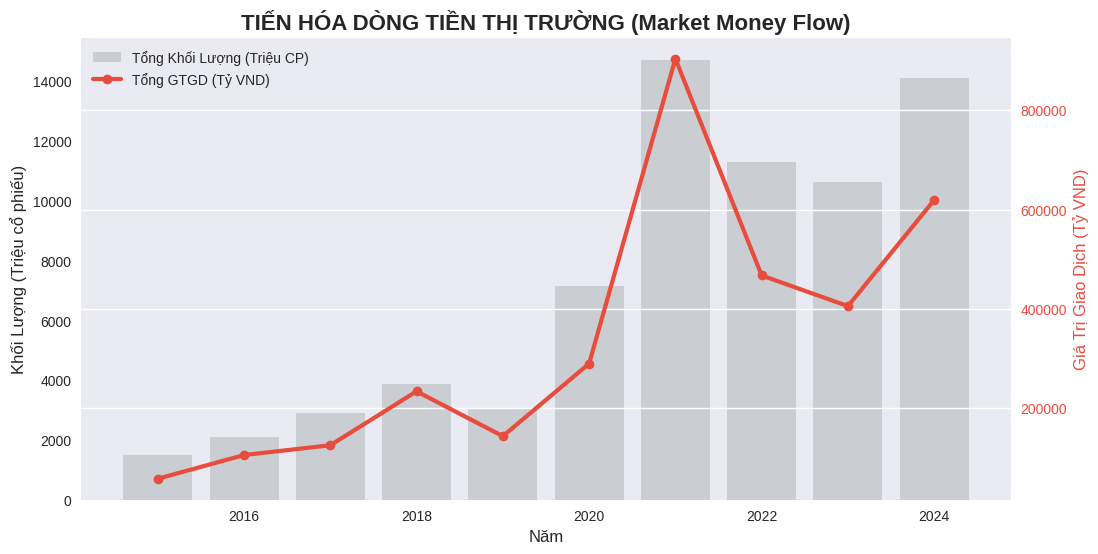

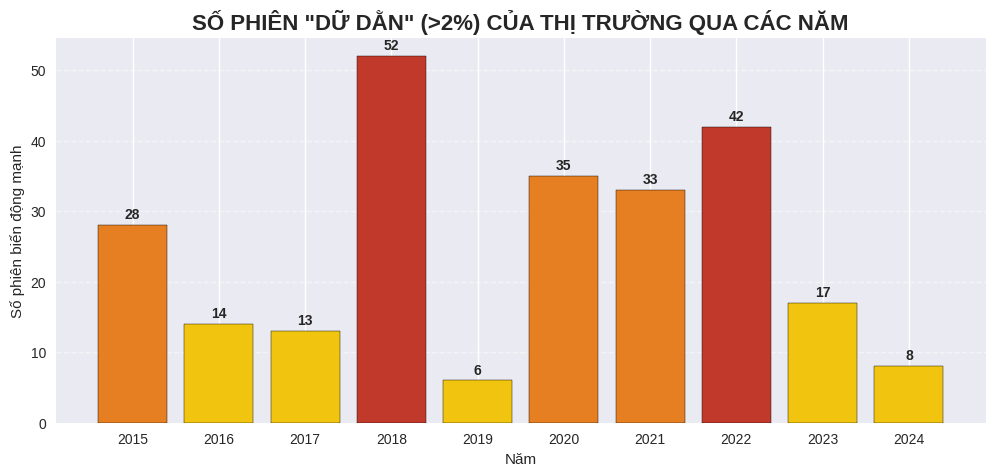

In [15]:
analyze_market_cash_flow()

In [16]:
all_stocks = [
    (ind, sym) for ind in ind_sym.keys() for sym in ind_sym[ind] 
]
print(all_stocks)

[('BatDongSan_XayDung', 'AAV'), ('BatDongSan_XayDung', 'ACC'), ('BatDongSan_XayDung', 'ACS'), ('BatDongSan_XayDung', 'AGG'), ('BatDongSan_XayDung', 'ALV'), ('BatDongSan_XayDung', 'AME'), ('BatDongSan_XayDung', 'ASM'), ('BatDongSan_XayDung', 'BAX'), ('BatDongSan_XayDung', 'BCC'), ('BatDongSan_XayDung', 'BCE'), ('BatDongSan_XayDung', 'BCM'), ('BatDongSan_XayDung', 'BDT'), ('BatDongSan_XayDung', 'BHC'), ('BatDongSan_XayDung', 'BIG'), ('BatDongSan_XayDung', 'BII'), ('BatDongSan_XayDung', 'BMJ'), ('BatDongSan_XayDung', 'BMP'), ('BatDongSan_XayDung', 'BTD'), ('BatDongSan_XayDung', 'BTN'), ('BatDongSan_XayDung', 'BTS'), ('BatDongSan_XayDung', 'BTU'), ('BatDongSan_XayDung', 'BVL'), ('BatDongSan_XayDung', 'C21'), ('BatDongSan_XayDung', 'C32'), ('BatDongSan_XayDung', 'C47'), ('BatDongSan_XayDung', 'C4G'), ('BatDongSan_XayDung', 'C69'), ('BatDongSan_XayDung', 'C92'), ('BatDongSan_XayDung', 'CBI'), ('BatDongSan_XayDung', 'CC1'), ('BatDongSan_XayDung', 'CCI'), ('BatDongSan_XayDung', 'CCL'), ('BatDo

Đang tổng hợp dữ liệu thị trường...


/tmp/ipykernel_2118752/141124468.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  daily_returns[symbol] = series_ret
/tmp/ipykernel_2118752/141124468.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  daily_returns[symbol] = series_ret
/tmp/ipykernel_2118752/141124468.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `

  - Bỏ qua NVT (Chưa download)


/tmp/ipykernel_2118752/141124468.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  daily_returns[symbol] = series_ret
/tmp/ipykernel_2118752/141124468.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  daily_returns[symbol] = series_ret
/tmp/ipykernel_2118752/141124468.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `

  - Bỏ qua SCI (Chưa download)


/tmp/ipykernel_2118752/141124468.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  daily_returns[symbol] = series_ret
/tmp/ipykernel_2118752/141124468.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  daily_returns[symbol] = series_ret
/tmp/ipykernel_2118752/141124468.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `

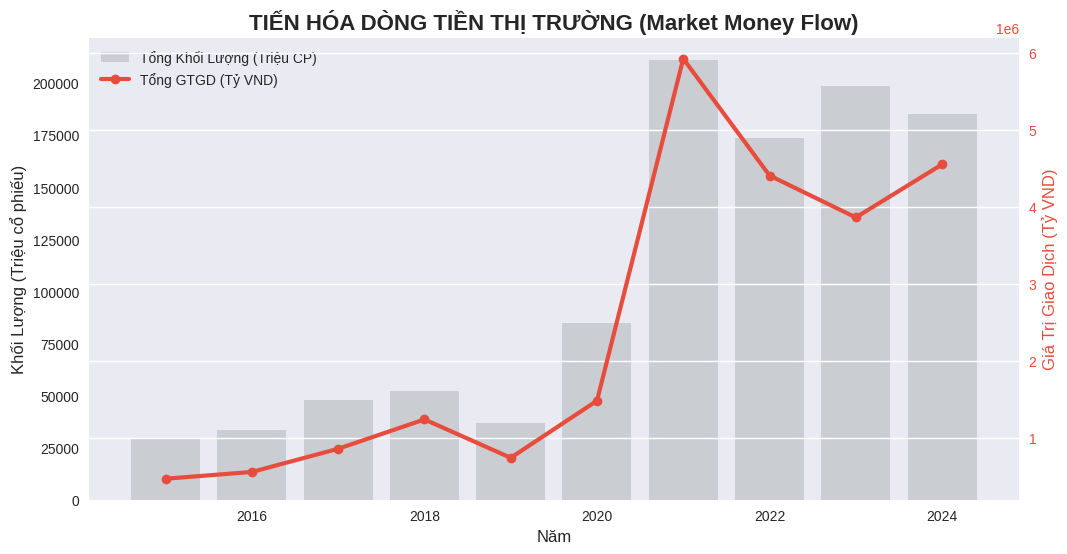

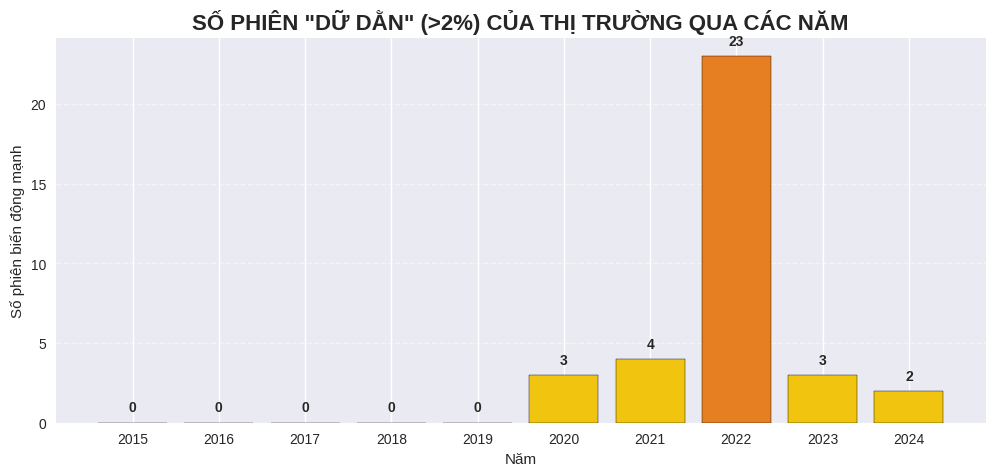

In [17]:
analyze_market_cash_flow(all_stocks)

In [18]:
def process_market_data_advanced(stock_list):
    print(f"Đang xử lý {len(stock_list)} mã cổ phiếu (Advanced Mode)...")
    
    yearly_stats = [] 
    # Lưu Return và cả Giá trị giao dịch để lọc Top thanh khoản
    market_data_store = [] 
    
    for industry, symbol in stock_list:
        path = f"{DATA_FOLDER}/{industry}/{symbol}/Price_History.csv"
        if not os.path.exists(path): continue
            
        try:
            df = pd.read_csv(path)
            df['Ngay'] = pd.to_datetime(df['Ngay'])
            
            # Drop duplicates & Sort
            df = df.drop_duplicates(subset=['Ngay'], keep='last').sort_values('Ngay')
            
            # 1. Tính toán cho Quy Mô (Giữ nguyên)
            df['Year'] = df['Ngay'].dt.year
            yr_data = df.groupby('Year')[['KhoiLuongKhopLenh', 'GiaTriKhopLenh']].sum().reset_index()
            yr_data['Symbol'] = symbol
            yearly_stats.append(yr_data)
            
            # 2. Chuẩn bị data cho Volatility
            # Chỉ lấy cột cần thiết để tiết kiệm RAM
            temp_df = df[['Ngay', 'GiaDongCua', 'GiaTriKhopLenh']].copy()
            temp_df['Return'] = temp_df['GiaDongCua'].pct_change()
            temp_df['Symbol'] = symbol
            market_data_store.append(temp_df)
            
        except Exception: continue

    # --- TỔNG HỢP ---
    if not yearly_stats: return None, None

    # 1. Tổng hợp Quy Mô (Dễ)
    df_scale = pd.concat(yearly_stats)
    market_scale = df_scale.groupby('Year')[['KhoiLuongKhopLenh', 'GiaTriKhopLenh']].sum()
    
    # 2. Tổng hợp Volatility (Xử lý nâng cao)
    print("Đang tính toán chỉ số biến động (Smart Index)...")
    full_df = pd.concat(market_data_store)
    
    # Group theo Ngày để xử lý từng phiên
    daily_groups = full_df.groupby('Ngay')
    
    smart_index_returns = {}
    
    for date, group in daily_groups:
        # LỌC NHIỄU: Chỉ lấy Top 50 mã có GTGD lớn nhất phiên đó để tính Index
        # Điều này loại bỏ các mã rác/penny không giao dịch làm nhiễu chỉ số
        top_liquidity = group.nlargest(50, 'GiaTriKhopLenh')
        
        # Tính trung bình return của Top 50 này
        if not top_liquidity.empty:
            avg_ret = top_liquidity['Return'].mean()
            smart_index_returns[date] = avg_ret
            
    # Chuyển về Series
    market_daily_ret = pd.Series(smart_index_returns).sort_index()
    
    return market_scale, market_daily_ret

In [21]:
market_scale, market_daily_ret = process_market_data_advanced(all_stocks)

Đang xử lý 1477 mã cổ phiếu (Advanced Mode)...
Đang tính toán chỉ số biến động (Smart Index)...


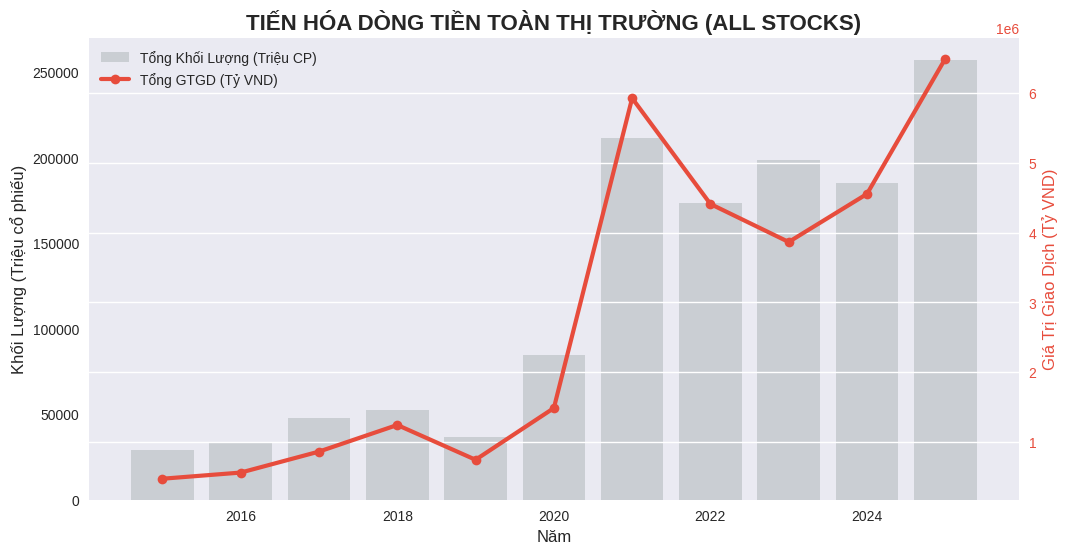

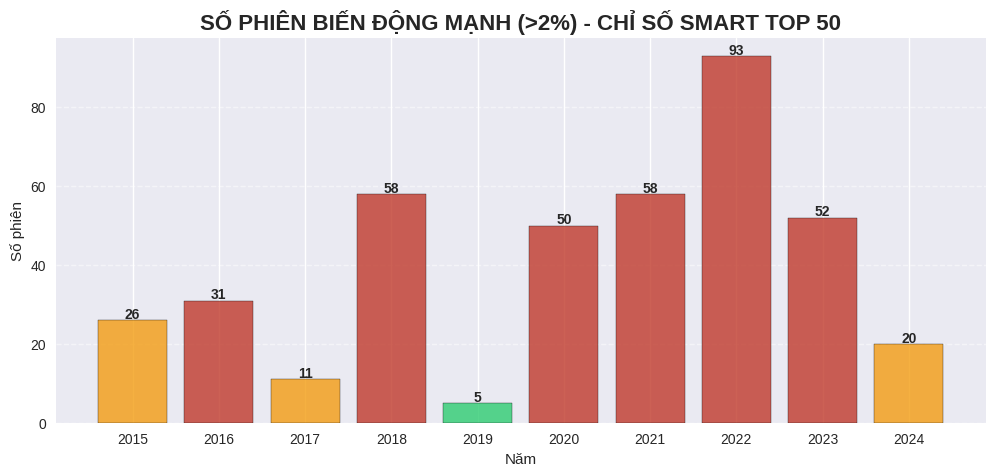

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# ======================================================
# LỌC DỮ LIỆU 10 NĂM (2015 - 2024)
# ======================================================
# Đổi tên biến cho khớp với code vẽ cũ
df_scale = market_scale.loc[2015:2025] # Lấy dư ra 2025 nếu có
s_ret = market_daily_ret[market_daily_ret.index.year >= 2015]

# ======================================================
# CHART 1: TIẾN HÓA DÒNG TIỀN (MONEY FLOW)
# ======================================================
fig, ax1 = plt.subplots(figsize=(12, 6))

# Trục 1: Bar chart (Volume)
# Chia 1 triệu để đơn vị là "Triệu cổ phiếu"
bars = ax1.bar(df_scale.index, df_scale['KhoiLuongKhopLenh'] / 1_000_000, 
               color='#bdc3c7', alpha=0.7, label='Tổng Khối Lượng (Triệu CP)')
ax1.set_xlabel('Năm', fontsize=12)
ax1.set_ylabel('Khối Lượng (Triệu cổ phiếu)', fontsize=12)
ax1.grid(False)

# Trục 2: Line chart (Value)
# Chia 1 tỷ để đơn vị là "Tỷ VND"
ax2 = ax1.twinx()
line = ax2.plot(df_scale.index, df_scale['GiaTriKhopLenh'] / 1_000_000_000, 
                color='#e74c3c', marker='o', linewidth=3, label='Tổng GTGD (Tỷ VND)')
ax2.set_ylabel('Giá Trị Giao Dịch (Tỷ VND)', fontsize=12, color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

plt.title('TIẾN HÓA DÒNG TIỀN TOÀN THỊ TRƯỜNG (ALL STOCKS)', fontsize=16, fontweight='bold')
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')
plt.show()

# ======================================================
# CHART 2: ĐỘ "DỮ DẰN" (VOLATILITY - SMART INDEX)
# ======================================================
# Logic: Đếm số phiên Top 50 thanh khoản tăng/giảm trung bình > 2%

# Tạo DataFrame
df_ret = s_ret.to_frame(name='Return')
df_ret['Year'] = df_ret.index.year

# Lọc những ngày biến động mạnh (abs > 2%)
volatile_days = df_ret[df_ret['Return'].abs() > 0.02]

# Đếm số phiên theo năm
vol_count = volatile_days.groupby('Year')['Return'].count()
# Reindex cho đủ năm
vol_count = vol_count.reindex(range(2015, 2025), fill_value=0)

# Vẽ Chart
plt.figure(figsize=(12, 5))
# Tô màu: Xanh (ít) -> Cam (vừa) -> Đỏ (nguy hiểm)
colors = ['#2ecc71' if x < 10 else '#f39c12' if x < 30 else '#c0392b' for x in vol_count]

bars = plt.bar(vol_count.index, vol_count.values, color=colors, edgecolor='black', alpha=0.8)

plt.title('SỐ PHIÊN BIẾN ĐỘNG MẠNH (>2%) - CHỈ SỐ SMART TOP 50', fontsize=16, fontweight='bold')
plt.xlabel('Năm')
plt.ylabel('Số phiên')
plt.xticks(range(2015, 2025))

# Thêm số trên cột
for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()